In [1]:
# 0. Import

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import celloracle as co
co.__version__

/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def dna_to_twobit(dna: str) -> int:


1 package does not meet CellOracle requirement.
 Your igraph version is 0.9.11. Please install igraph>=0.10.1


'0.14.0'

In [2]:
!mkdir "../process/regulation/20250110_celloracle/"

In [3]:
save_folder = "../process/regulation/20250110_celloracle/"

In [4]:
# visualization settings
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

os.makedirs(save_folder, exist_ok=True)

In [5]:
adata = sc.read_h5ad("../../2024.4_scATAC/data/palate_epi_MAGIC_periderm_MAGIC_harmony_renamed.h5ad")

In [6]:
adata.layers["raw_count"] = adata.X.copy()
# Only consider genes with more than 1 count
sc.pp.filter_genes(adata, min_counts=1)
# Normalize gene expression matrix with total UMI count per cell
sc.pp.normalize_per_cell(adata, key_n_counts='n_counts_all')



In [7]:

filter_result = sc.pp.filter_genes_dispersion(adata.X,
                                              flavor='cell_ranger',
                                              n_top_genes=2000,
                                              log=False)

In [8]:
drawgraphEmb = pd.read_csv("../../2024.4_scATAC/processed_data/embedding/RNA_scvi_20neibor_drawgraph.csv",index_col=0)
adata.obsm["X_draw_graph_fa"] = np.array(drawgraphEmb)
adata.uns["draw_graph"] = {'params': {'layout': 'fa', 'random_state': 0}}

In [9]:
tfDict = pd.read_csv("../process/20241226_scenicplus_outs/20250107_tf2gene.csv",index_col=0)

In [11]:
tfDict["TF"].unique()

array(['Atf3', 'Atf7', 'Bach1', 'Cebpa', 'Cebpb', 'Cebpg', 'Ctcf',
       'Ctnnb1', 'Dlx1', 'Dlx2', 'Dlx3', 'Dlx5', 'E2f1', 'E2f2', 'E2f3',
       'E2f4', 'E2f6', 'E2f7', 'Egr1', 'Etv4', 'Etv5', 'Fos', 'Fosb',
       'Fosl2', 'Foxa1', 'Foxp2', 'Grhl2', 'Irf6', 'Jdp2', 'Jun', 'Junb',
       'Jund', 'Klf12', 'Klf13', 'Klf4', 'Klf5', 'Klf7', 'Lef1', 'Maf',
       'Mafb', 'Maff', 'Mafg', 'Mafk', 'Maz', 'Meis2', 'Meis3', 'Meox1',
       'Msx1', 'Msx2', 'Nfe2l2', 'Nfia', 'Nfib', 'Nfic', 'Nfix', 'Nfkb2',
       'Nfyb', 'Nfyc', 'Nr6a1', 'Nrf1', 'Otx1', 'Pbx1', 'Pitx1', 'Pitx2',
       'Plagl1', 'Prrx2', 'Rara', 'Rela', 'Rfx3', 'Rfx7', 'Runx1', 'Six2',
       'Six4', 'Smad3', 'Sox11', 'Sox13', 'Sox2', 'Sox21', 'Sox4', 'Sox5',
       'Sox6', 'Sox9', 'Sp5', 'Sp6', 'Tcf3', 'Tcf7l2', 'Tead1', 'Tfap2a',
       'Tfap2b', 'Tfap2c', 'Tfdp1', 'Tgif1', 'Thra', 'Trp63', 'Yy1',
       'Atf1', 'Atf4', 'Atf6', 'Chd2', 'Creb1', 'Elf1', 'Elf2', 'Elk3',
       'Ets2', 'Isl1', 'Klf3', 'Nfat5', 'Pbx3', 'Rarg', 'R

In [12]:
varGene = adata.var_names[filter_result.gene_subset]
varGene = list(varGene)


In [16]:
len(tfDict["TF"].unique())

227

In [19]:
varGene= list(set(varGene +list(tfDict["TF"].unique())))

In [21]:
len(varGene)

2159

In [22]:
cluster_info = pd.read_csv("../../2024.4_scATAC/processed_data/cluster/rna_annotation_scvi_mod.csv",index_col=0)
adata.obs[cluster_info.columns] = cluster_info

In [23]:
adata=adata[:,varGene]

In [31]:
adata

View of AnnData object with n_obs × n_vars = 19404 × 2159
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'group', 'SCT_snn_res.0.6', 'celltype', 'SCT_snn_res.0.4', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'ident', 'n_counts_all', 'level1_anno', 'level2_anno'
    var: 'n_counts'
    uns: 'X_name', 'draw_graph'
    obsm: 'HARMONY', 'PCA', 'UMAP', 'X_draw_graph_fa'
    layers: 'logcounts', 'raw_count'

In [32]:
sc.pp.filter_genes(adata, min_cells=10)

In [33]:
adata

AnnData object with n_obs × n_vars = 19404 × 2077
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'group', 'SCT_snn_res.0.6', 'celltype', 'SCT_snn_res.0.4', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'ident', 'n_counts_all', 'level1_anno', 'level2_anno'
    var: 'n_counts', 'n_cells'
    uns: 'X_name', 'draw_graph'
    obsm: 'HARMONY', 'PCA', 'UMAP', 'X_draw_graph_fa'
    layers: 'logcounts', 'raw_count'

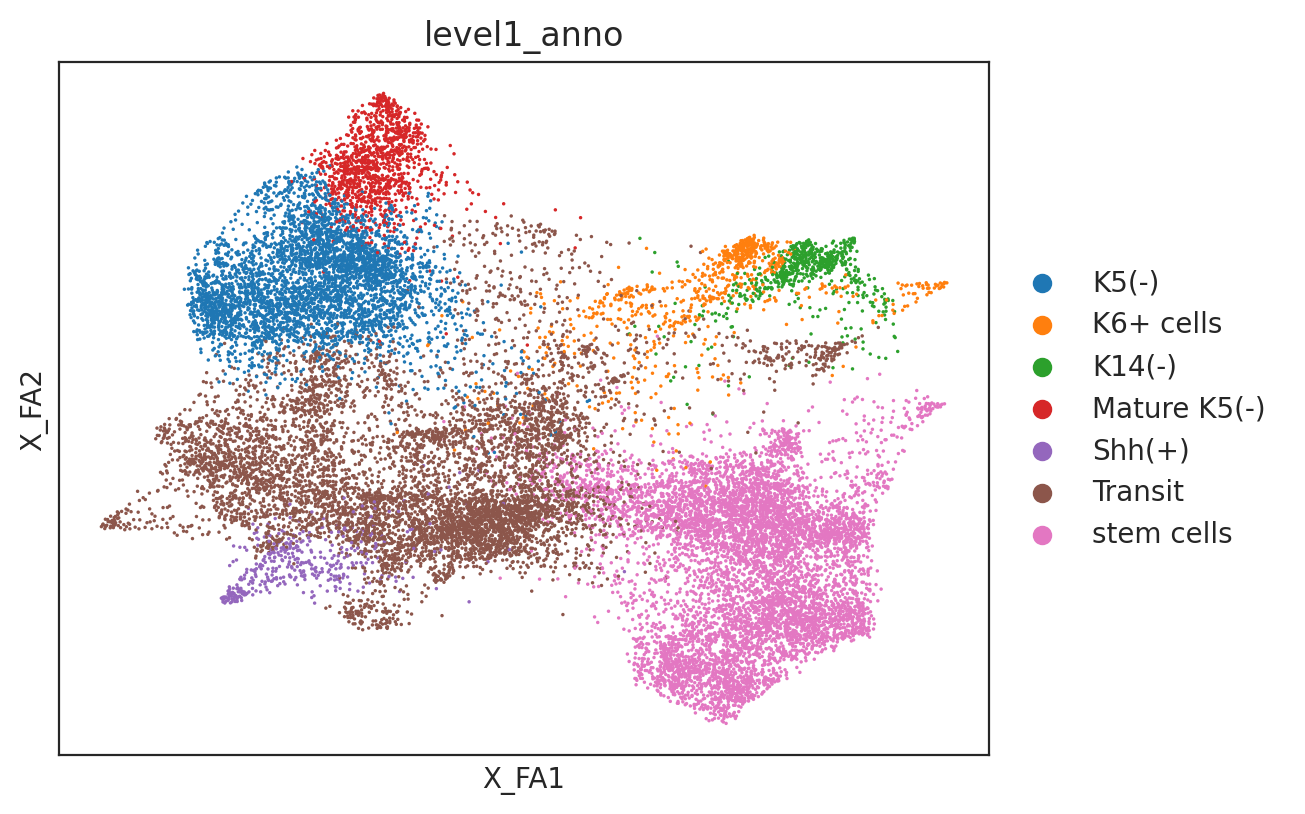

In [34]:
# Instantiate Oracle object
oracle = co.Oracle()
# In this notebook, we use the unscaled mRNA count for the nput of Oracle object.
adata.X = adata.layers["raw_count"].copy()

# Instantiate Oracle object.
oracle.import_anndata_as_raw_count(adata=adata,
                                   cluster_column_name="level1_anno",
                                   embedding_name="X_draw_graph_fa")

In [35]:
tf_to_genes = {tf: tfDict[tfDict['TF'] == tf]['Gene'].tolist() for tf in tfDict['TF'].unique()}


In [36]:
TG_to_TF_dictionary = co.utility.inverse_dictionary(tf_to_genes)

  0%|          | 0/7052 [00:00<?, ?it/s]

In [37]:
oracle.import_TF_data(TFdict = TG_to_TF_dictionary)

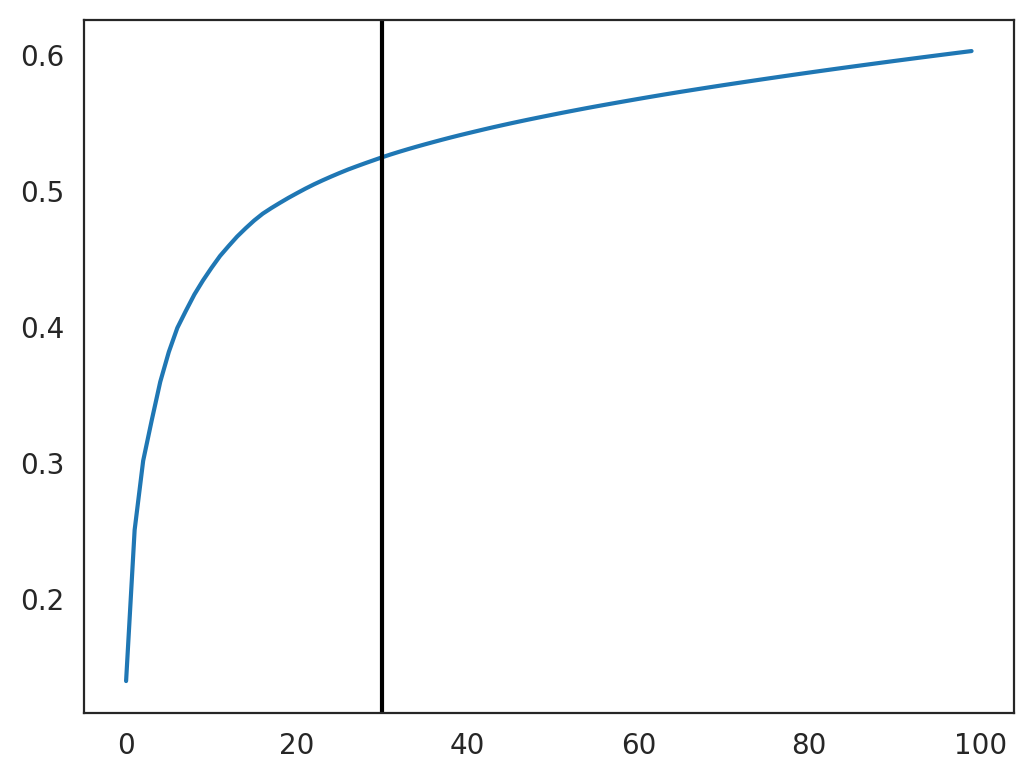

30


In [38]:
# Perform PCA
oracle.perform_PCA()

# Select important PCs
plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.002))[0][0]
plt.axvline(n_comps, c="k")
plt.show()
print(n_comps)
n_comps = min(n_comps, 50)

In [39]:
int(0.025*n_cell)

485

In [40]:
n_cell = oracle.adata.shape[0]
print(f"cell number is :{n_cell}")
k = int(0.025*n_cell)
print(f"Auto-selected k is :{k}")
oracle.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8,
                      b_maxl=k*4, n_jobs=40)

cell number is :19404
Auto-selected k is :485


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fd71aa06940>
Traceback (most recent call last):
  File "/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


In [41]:
# Save oracle object.
oracle.to_hdf5(f"{save_folder}/20250110_rna.celloracle.oracle")

In [42]:
%%time
# Calculate GRN for each population in "louvain_annot" clustering unit.
# This step may take some time.(~30 minutes)
links = oracle.get_links(cluster_name_for_GRN_unit="level1_anno", alpha=10,
                         verbose_level=10)

  0%|          | 0/7 [00:00<?, ?it/s]

Inferring GRN for K14(-)...


  0%|          | 0/1055 [00:00<?, ?it/s]

Inferring GRN for K5(-)...


  0%|          | 0/1055 [00:00<?, ?it/s]

...

Inferring GRN for Transit...


  0%|          | 0/1055 [00:00<?, ?it/s]

Inferring GRN for stem cells...


  0%|          | 0/1055 [00:00<?, ?it/s]

CPU times: user 14min 27s, sys: 1min 7s, total: 15min 34s
Wall time: 17min 35s


In [43]:
# Save Links object.
links.to_hdf5(file_path=f"{save_folder}/20250110_rna_links.celloracle.links")

In [44]:
links.filter_links(p=0.001, weight="coef_abs", threshold_number=2000)

K14(-)


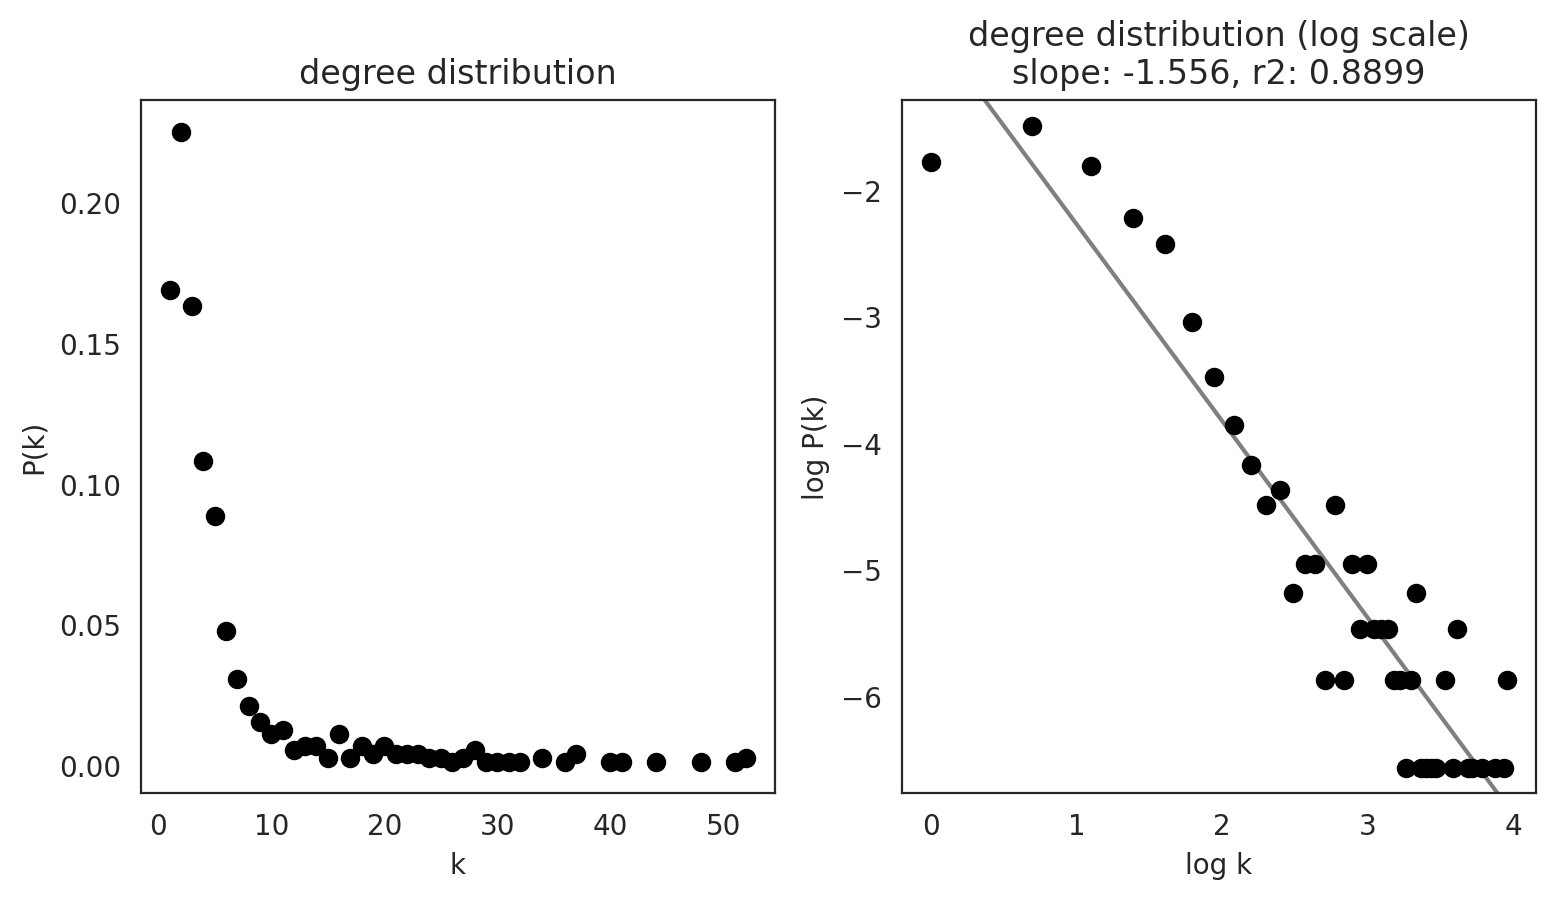

K5(-)


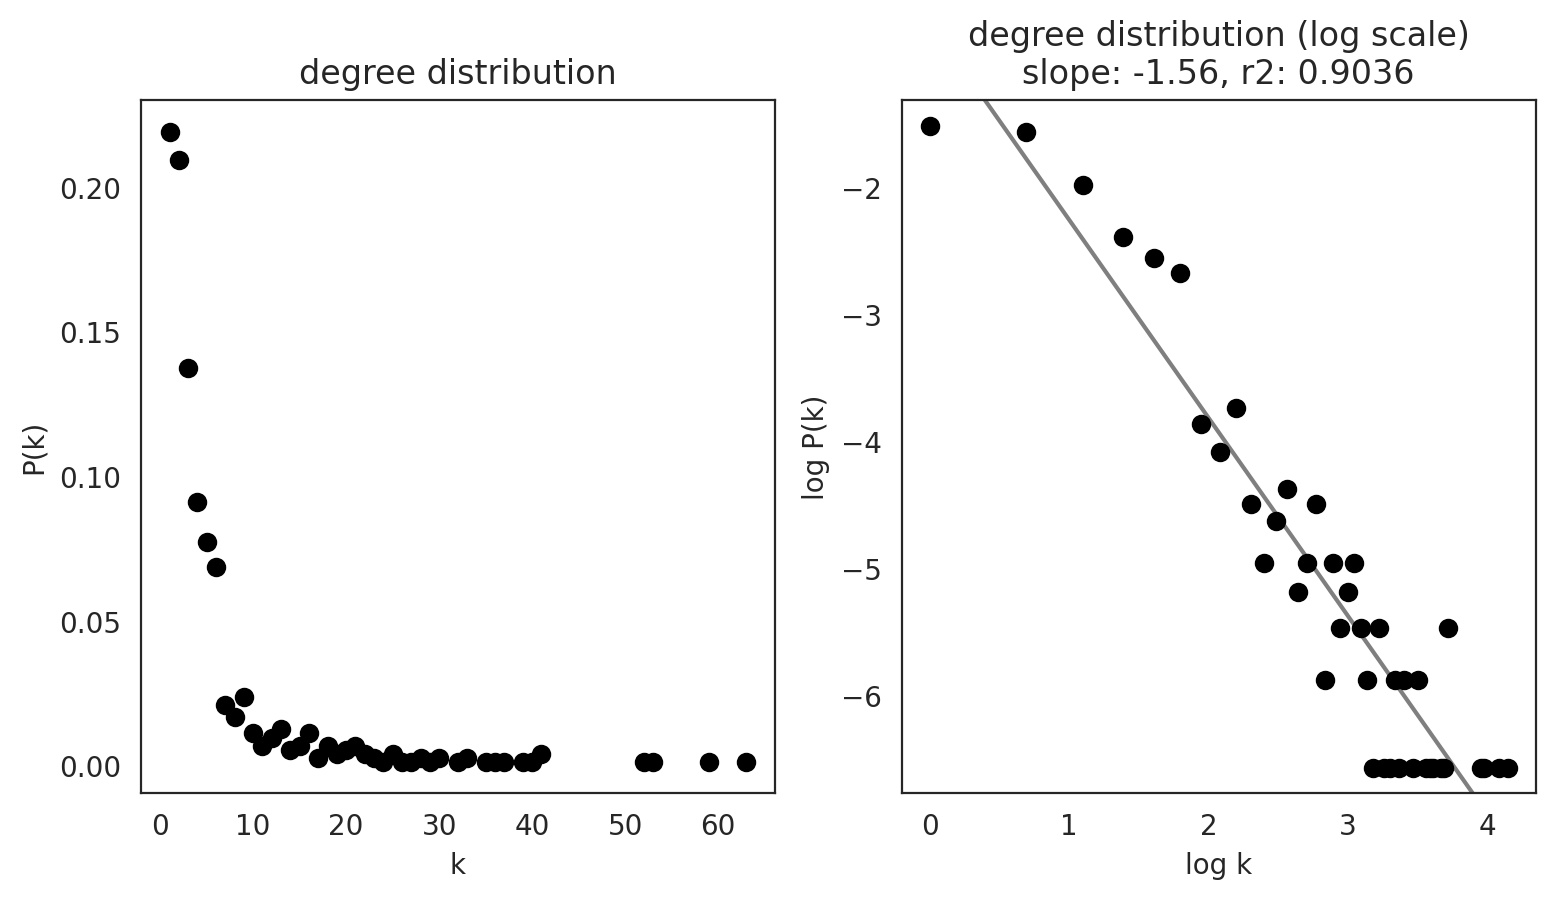

K6+ cells


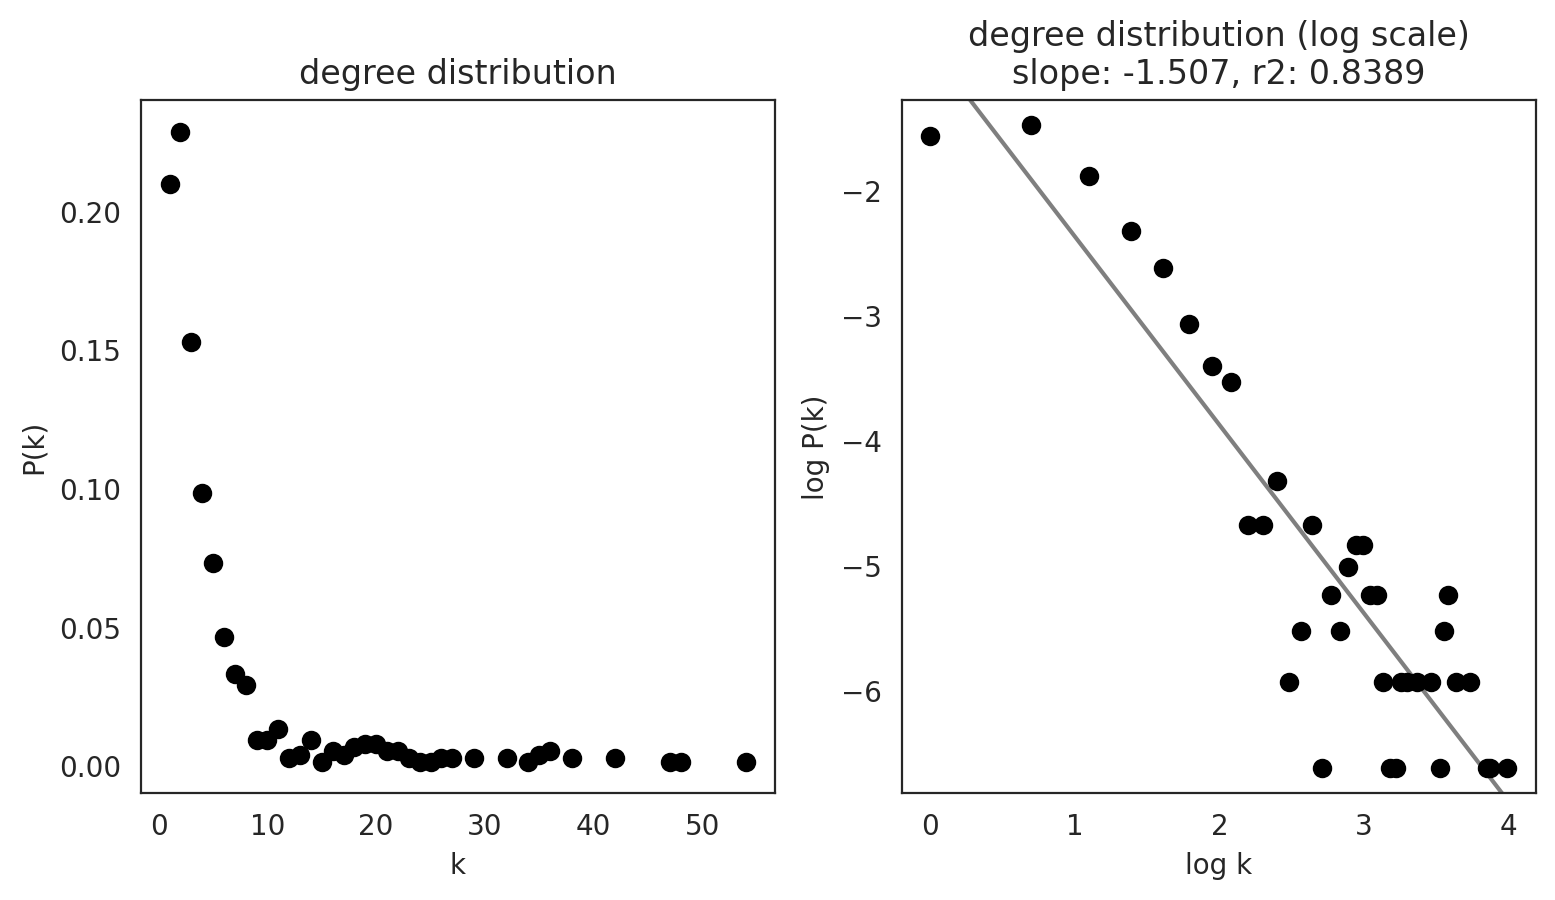

Mature K5(-) 


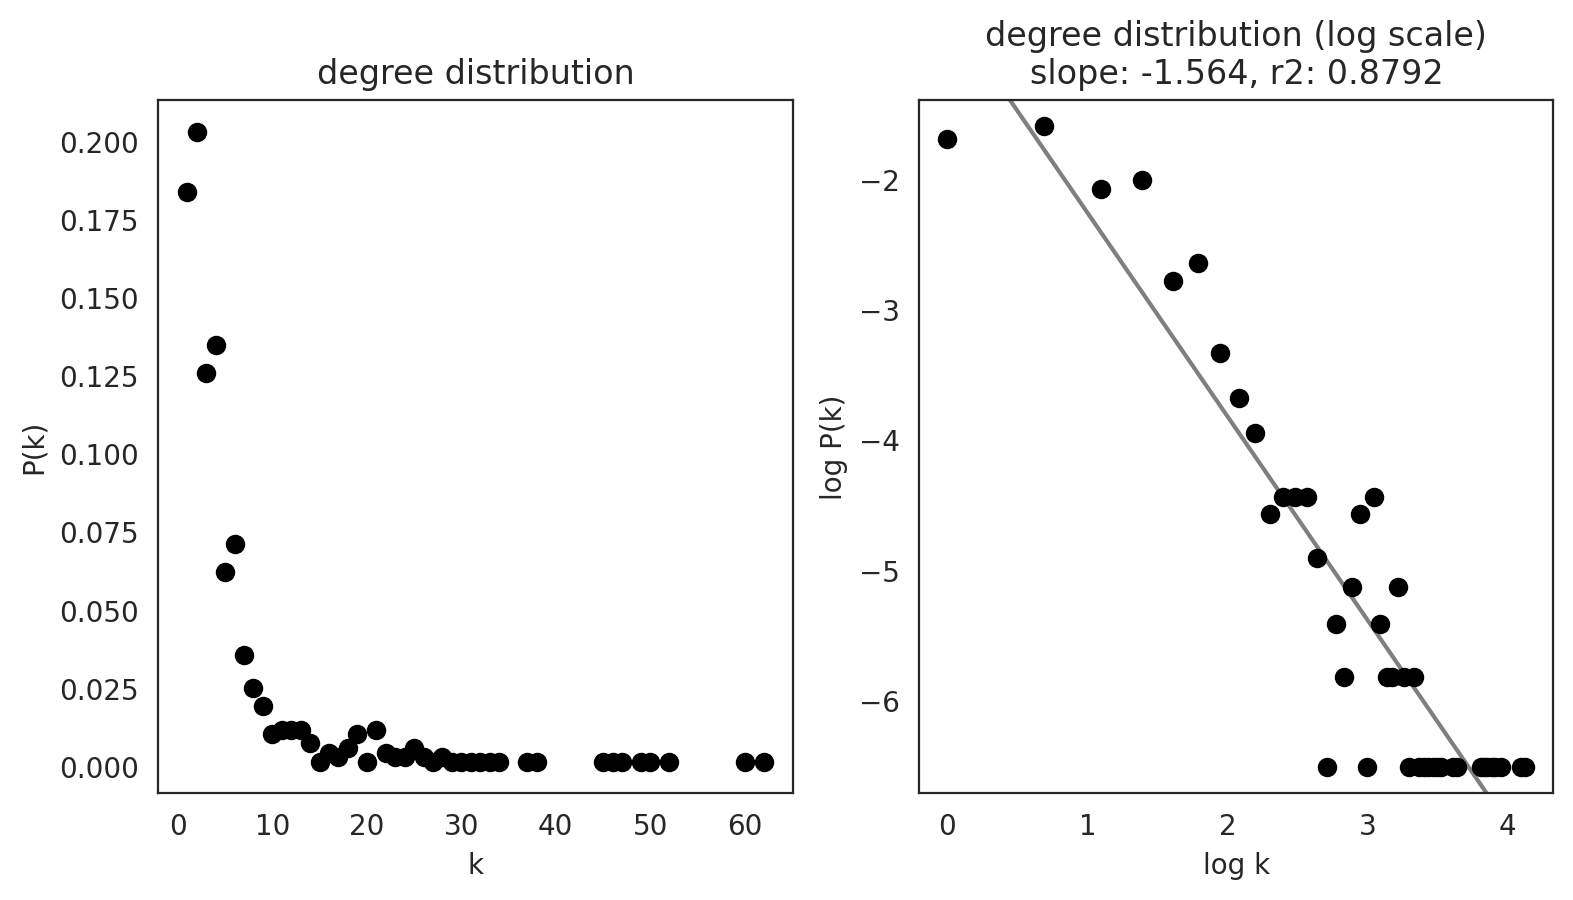

Shh(+)


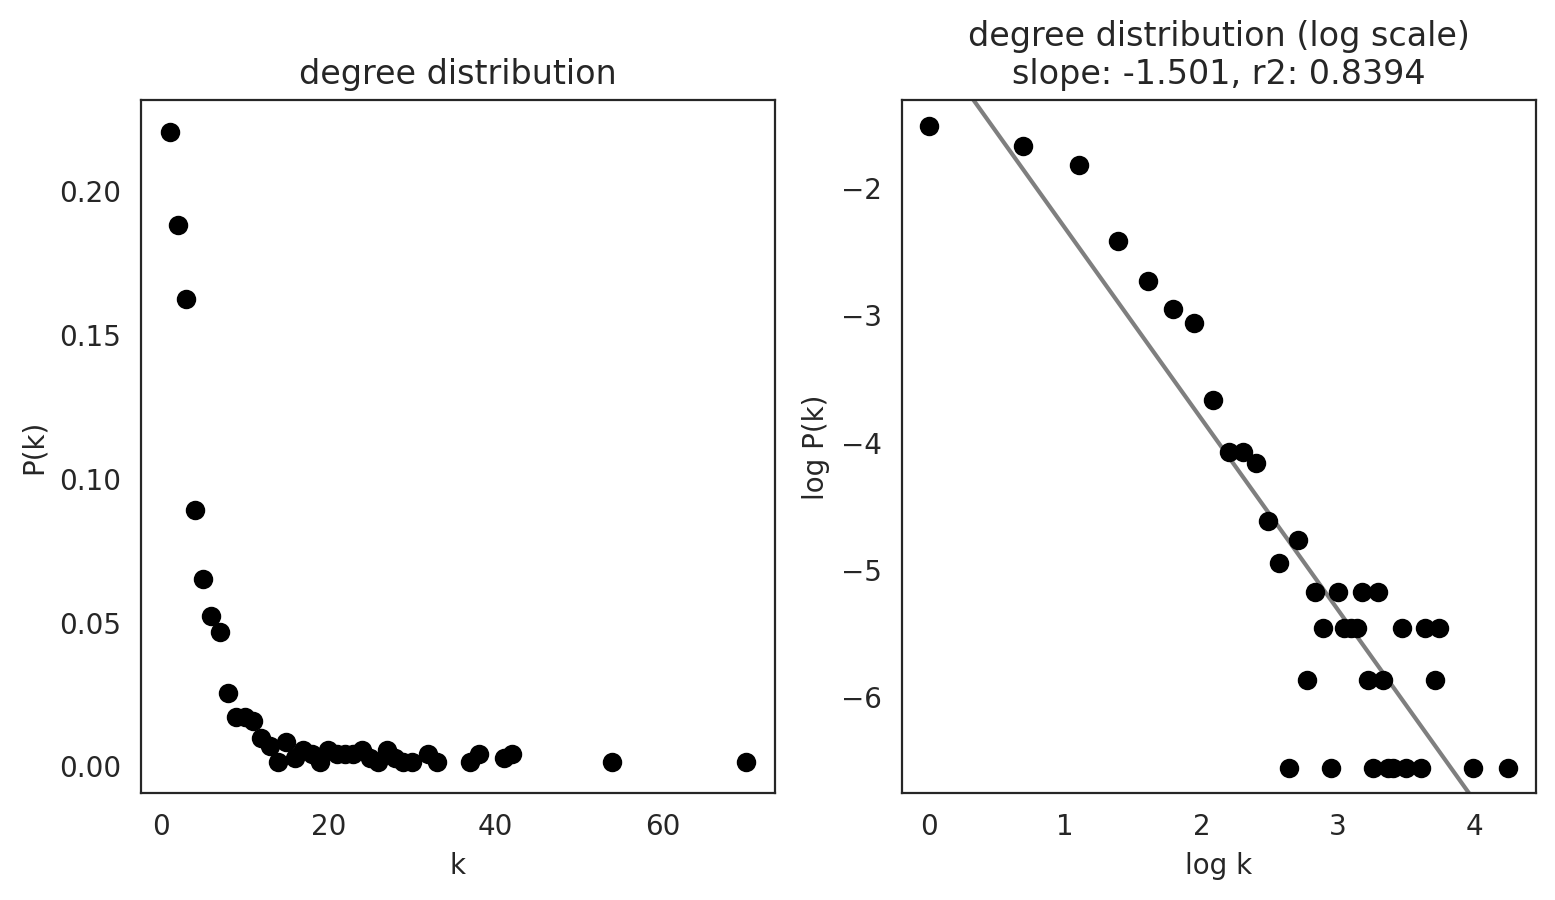

Transit


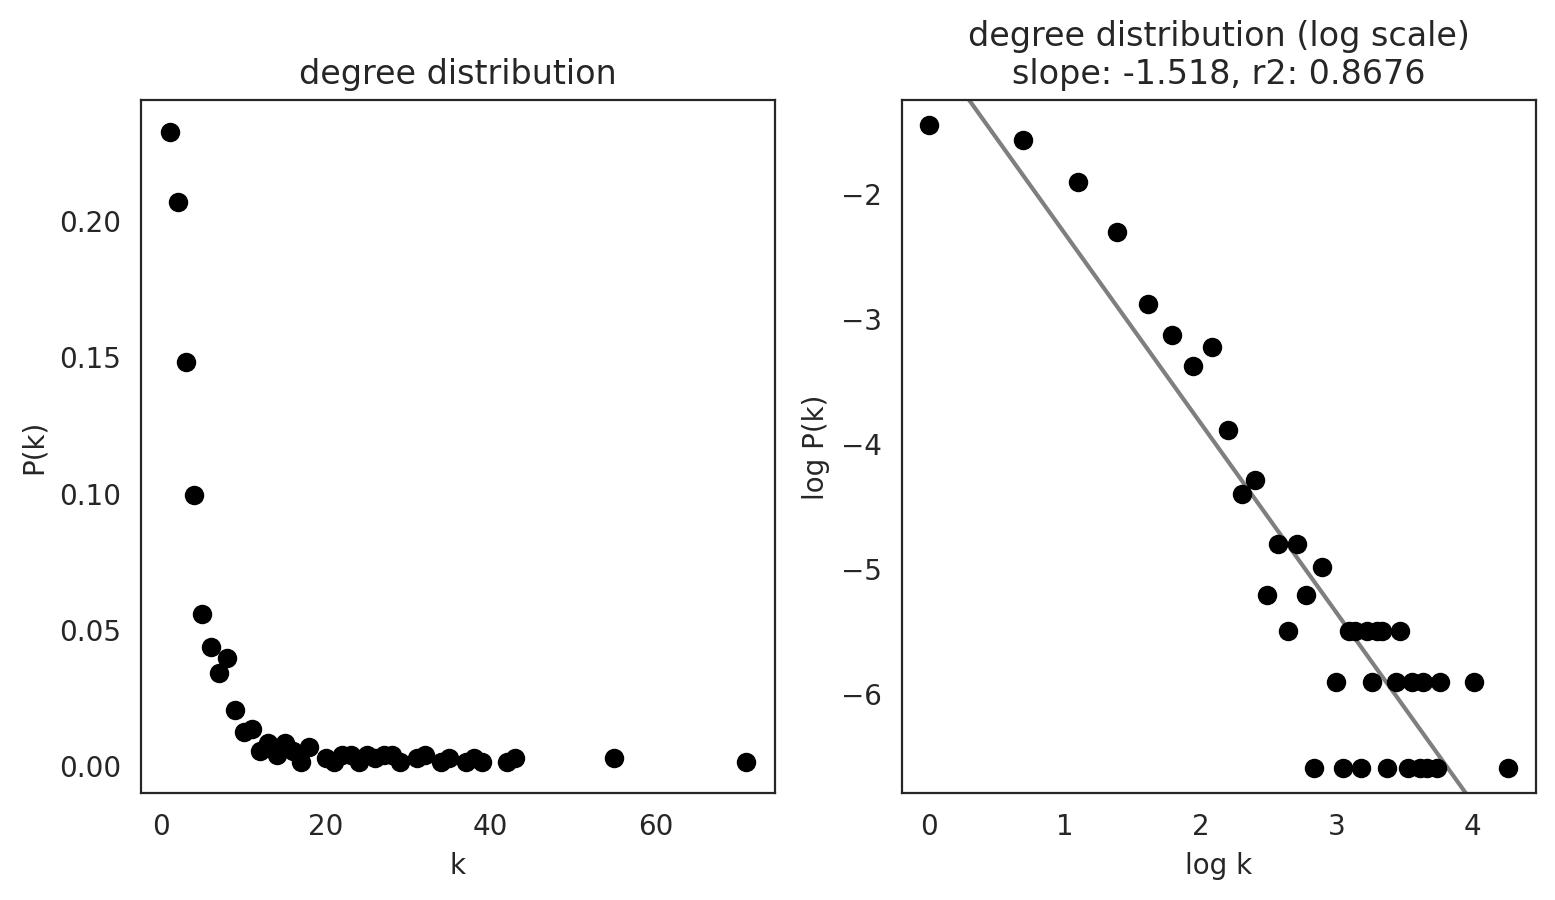

stem cells


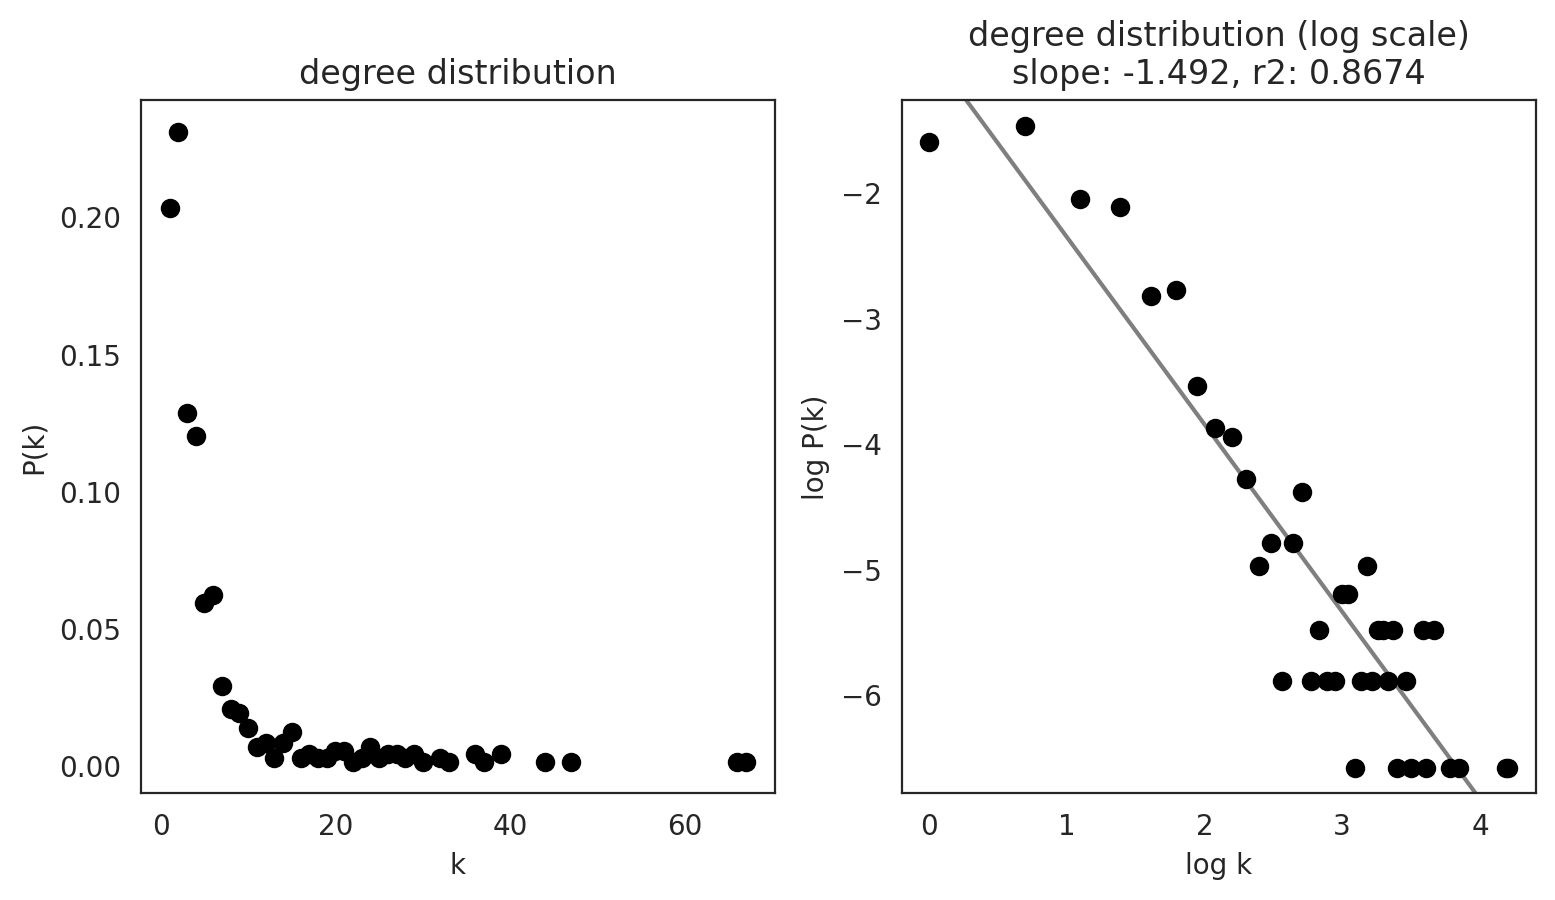

In [45]:
plt.rcParams["figure.figsize"] = [9, 4.5]
links.plot_degree_distributions(plot_model=True,
                                               save=f"{save_folder}/degree_distribution/",
                                               )

In [46]:
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)
oracle.fit_GRN_for_simulation(alpha=10,
                              use_cluster_specific_TFdict=True)

  0%|          | 0/7 [00:00<?, ?it/s]

In [47]:
# Save oracle object.
oracle.to_hdf5(f"{save_folder}/20250110_rna.celloracle.oracle")

In [48]:
TFUniuqe = list(set(tfDict["TF"]))
TFIntersect = np.intersect1d(TFUniuqe, varGene)

In [50]:
pd.DataFrame(TFIntersect).to_csv("../process/regulation/20250107_celloracle/20250107_TF2.csv")